### Cell 2. import / 설정

In [2]:
import os
import json
import random
from collections import Counter, defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

from transformers import AutoImageProcessor, SiglipVisionModel

/home/eraale/WS_linux/26yaicon1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATA_DIR = "arena_scene_dataset"

MODEL_NAME = "google/siglip-base-patch16-224"
SAVE_PATH = "siglip_scene_descriptor.pt"

# 기존 9-class checkpoint의 encoder를 재사용하고 싶으면 True
LOAD_ENCODER_FROM_9CLASS = True
OLD_9CLASS_CKPT_PATH = "siglip_arena_classifier.pt"

IMAGE_SIZE = 224

BATCH_SIZE = 16
EPOCHS = 5
LR = 2e-5
VAL_RATIO = 0.15
SEED = 42

FREEZE_ENCODER = False
USE_AMP = True

### Cell 3. label mapping

In [7]:
TYPE_NAMES = ["none", "zombie", "skeleton"]

DISTANCE_BIN_NAMES = [
    "none",
    "too_close",
    "attackable",
    "near",
    "far",
]

HORIZONTAL_BIN_NAMES = [
    "none",
    "center",
    "left",
    "right",
    "far_left",
    "far_right",
]

VERTICAL_BIN_NAMES = [
    "middle",
    "up",
    "down",
]

COUNT_BIN_NAMES = [
    "0",
    "1",
    "2",
    "3",
    "4+",
]

HEAD_DIMS = {
    "nearest_type": len(TYPE_NAMES),
    "nearest_distance": len(DISTANCE_BIN_NAMES),
    "nearest_horizontal": len(HORIZONTAL_BIN_NAMES),
    "nearest_vertical": len(VERTICAL_BIN_NAMES),
    "visible_entity_count": len(COUNT_BIN_NAMES),
    "visible_zombie_count": len(COUNT_BIN_NAMES),
    "visible_skeleton_count": len(COUNT_BIN_NAMES),
}

BINARY_HEADS = [
    "has_visible_entity",
    "multiple_entities",
    "nearest_too_close",
    "nearest_attackable",
]

### Cell 4. GPU 확인 / seed

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

if device == "cuda":
    print(torch.cuda.get_device_name(0))
    print("VRAM GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)

device: cuda
NVIDIA GeForce RTX 4070 SUPER
VRAM GB: 11.99365234375


In [9]:
def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

### Cell 5. 데이터 읽기

In [6]:
def clip_count(x):
    return min(int(x), 4)


def load_one_record(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    labels = data["scene_labels"]

    target = {
        # binary labels
        "has_visible_entity": float(labels["has_visible_entity"]),
        "multiple_entities": float(labels["multiple_entities"]),
        "nearest_too_close": float(labels["nearest_too_close"]),
        "nearest_attackable": float(labels["nearest_attackable"]),

        # categorical labels
        "nearest_type": int(labels["nearest_type_id"]),
        "nearest_distance": int(labels["nearest_distance_bin_id"]),
        "nearest_horizontal": int(labels["nearest_horizontal_bin_id"]),
        "nearest_vertical": int(labels["nearest_vertical_bin_id"]),

        "visible_entity_count": clip_count(labels["visible_entity_count"]),
        "visible_zombie_count": clip_count(labels["visible_zombie_count"]),
        "visible_skeleton_count": clip_count(labels["visible_skeleton_count"]),
    }

    return data, target


def load_samples(data_dir):
    samples = []

    for name in sorted(os.listdir(data_dir)):
        if not name.endswith(".json"):
            continue

        stem = os.path.splitext(name)[0]
        json_path = os.path.join(data_dir, name)
        image_path = os.path.join(data_dir, stem + ".png")

        if not os.path.exists(image_path):
            continue

        try:
            data, target = load_one_record(json_path)

            samples.append({
                "image_path": image_path,
                "json_path": json_path,
                "target": target,
                "scene_text": data.get("scene_text", ""),
                "mode_name": data.get("mode_name", "unknown"),
            })

        except Exception as e:
            print("skip:", json_path, e)

    return samples


samples = load_samples(DATA_DIR)
print("total samples:", len(samples))

total samples: 10020


### Cell 6. label 분포 확인

In [7]:
def print_distribution(samples, key, names=None):
    c = Counter([s["target"][key] for s in samples])
    print("\n", key)

    for k in sorted(c.keys()):
        if names is None:
            name = str(k)
        else:
            name = names[k]
        print(f"  {k}: {name:16s} {c[k]}")


print("mode distribution")
mode_counter = Counter([s["mode_name"] for s in samples])
for k, v in mode_counter.items():
    print(f"  {k:28s} {v}")

print_distribution(samples, "nearest_type", TYPE_NAMES)
print_distribution(samples, "nearest_distance", DISTANCE_BIN_NAMES)
print_distribution(samples, "nearest_horizontal", HORIZONTAL_BIN_NAMES)
print_distribution(samples, "nearest_vertical", VERTICAL_BIN_NAMES)
print_distribution(samples, "visible_entity_count", COUNT_BIN_NAMES)
print_distribution(samples, "visible_zombie_count", COUNT_BIN_NAMES)
print_distribution(samples, "visible_skeleton_count", COUNT_BIN_NAMES)

for key in BINARY_HEADS:
    print_distribution(samples, key)

mode distribution
  single_left                  1002
  multi_nearest_center         1002
  no_entity                    1002
  single_center_attackable     1002
  multi_nearest_left           1002
  mixed_zombie_skeleton        1002
  too_close                    1002
  single_center_far            1002
  multi_nearest_right          1002
  single_right                 1002

 nearest_type
  0: none             1031
  1: zombie           4458
  2: skeleton         4531

 nearest_distance
  0: none             1031
  1: too_close        1002
  2: attackable       3734
  3: near             2319
  4: far              1934

 nearest_horizontal
  0: none             1031
  1: center           3742
  2: left             1427
  3: right            1384
  4: far_left         1209
  5: far_right        1227

 nearest_vertical
  0: middle           3888
  2: down             6132

 visible_entity_count
  0: 0                1031
  1: 1                5520
  2: 2                1515
  3: 3      

### Cell 7. 이미지 확인

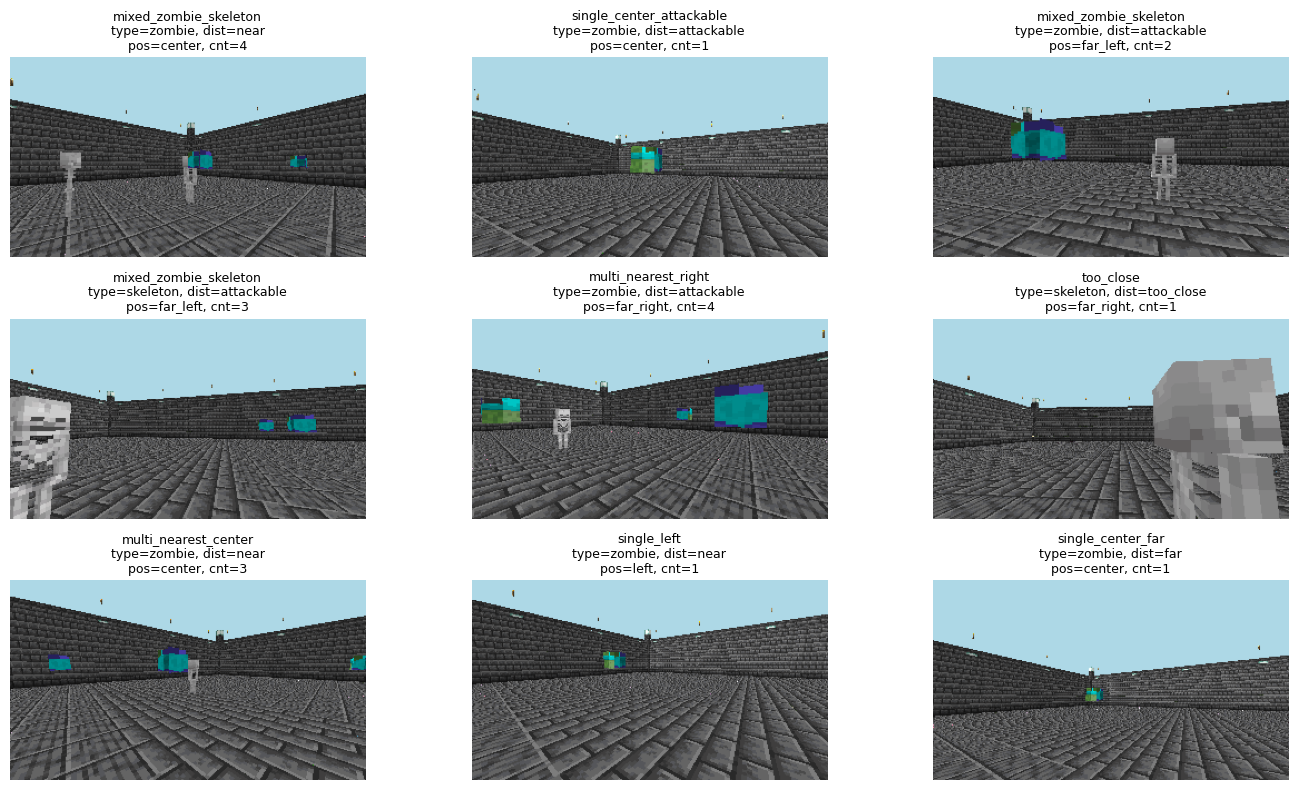

In [8]:
def show_random_samples(samples, n=9):
    picks = random.sample(samples, min(n, len(samples)))

    plt.figure(figsize=(14, 8))

    for i, s in enumerate(picks):
        img = Image.open(s["image_path"]).convert("RGB")

        t = s["target"]

        title = (
            f"{s['mode_name']}\n"
            f"type={TYPE_NAMES[t['nearest_type']]}, "
            f"dist={DISTANCE_BIN_NAMES[t['nearest_distance']]}\n"
            f"pos={HORIZONTAL_BIN_NAMES[t['nearest_horizontal']]}, "
            f"cnt={t['visible_entity_count']}"
        )

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(title, fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_random_samples(samples, 9)

### Cell 8. train / val split

In [10]:
stratify_labels = [s["mode_name"] for s in samples]

train_samples, val_samples = train_test_split(
    samples,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=stratify_labels,
)

print("train:", len(train_samples))
print("val:", len(val_samples))

print("train modes:", Counter([s["mode_name"] for s in train_samples]))
print("val modes:", Counter([s["mode_name"] for s in val_samples]))

train: 8517
val: 1503
train modes: Counter({'single_center_attackable': 852, 'mixed_zombie_skeleton': 852, 'multi_nearest_center': 852, 'too_close': 852, 'single_left': 852, 'multi_nearest_left': 852, 'single_right': 852, 'no_entity': 851, 'multi_nearest_right': 851, 'single_center_far': 851})
val modes: Counter({'multi_nearest_right': 151, 'no_entity': 151, 'single_center_far': 151, 'single_left': 150, 'too_close': 150, 'single_right': 150, 'multi_nearest_center': 150, 'single_center_attackable': 150, 'mixed_zombie_skeleton': 150, 'multi_nearest_left': 150})


### Cell 9. letterbox 전처리

In [11]:
def letterbox_to_square(image, size=224):
    image = image.convert("RGB")

    w, h = image.size
    scale = size / max(w, h)

    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    resized = image.resize((new_w, new_h), Image.BICUBIC)

    canvas = Image.new("RGB", (size, size), (0, 0, 0))

    left = (size - new_w) // 2
    top = (size - new_h) // 2

    canvas.paste(resized, (left, top))

    return canvas

### Cell 10. Dataset / DataLoader

In [12]:
class SceneDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        image = Image.open(s["image_path"]).convert("RGB")
        image = letterbox_to_square(image, IMAGE_SIZE)

        return {
            "image": image,
            "target": s["target"],
            "image_path": s["image_path"],
            "scene_text": s["scene_text"],
            "mode_name": s["mode_name"],
        }

In [13]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

def collate_fn(batch):
    images = [x["image"] for x in batch]

    inputs = processor(
        images=images,
        return_tensors="pt",
        do_resize=False,
    )

    targets = {}

    for key in BINARY_HEADS:
        targets[key] = torch.tensor(
            [x["target"][key] for x in batch],
            dtype=torch.float32,
        )

    for key in HEAD_DIMS.keys():
        targets[key] = torch.tensor(
            [x["target"][key] for x in batch],
            dtype=torch.long,
        )

    return {
        "pixel_values": inputs["pixel_values"],
        "targets": targets,
        "image_paths": [x["image_path"] for x in batch],
        "scene_texts": [x["scene_text"] for x in batch],
        "mode_names": [x["mode_name"] for x in batch],
    }

In [14]:
train_ds = SceneDataset(train_samples)
val_ds = SceneDataset(val_samples)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

## Cell 11. multi-head SigLIP 모델

In [12]:
class SiglipSceneDescriptor(nn.Module):
    def __init__(self, model_name):
        super().__init__()

        self.encoder = SiglipVisionModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.ce_heads = nn.ModuleDict({
            name: nn.Linear(hidden_size, dim)
            for name, dim in HEAD_DIMS.items()
        })

        self.binary_heads = nn.ModuleDict({
            name: nn.Linear(hidden_size, 1)
            for name in BINARY_HEADS
        })

        if FREEZE_ENCODER:
            for p in self.encoder.parameters():
                p.requires_grad = False

    def forward(self, pixel_values):
        out = self.encoder(pixel_values=pixel_values)

        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            feat = out.pooler_output
        else:
            feat = out.last_hidden_state.mean(dim=1)

        outputs = {}

        for name, head in self.ce_heads.items():
            outputs[name] = head(feat)

        for name, head in self.binary_heads.items():
            outputs[name] = head(feat).squeeze(-1)

        return outputs

### Cell 12. 기존 9-class encoder 가져오기

In [13]:
def load_encoder_from_9class(model, ckpt_path):
    if not os.path.exists(ckpt_path):
        print("old checkpoint not found:", ckpt_path)
        return

    ckpt = torch.load(ckpt_path, map_location="cpu")
    sd = ckpt["model_state_dict"]

    encoder_sd = {}

    for k, v in sd.items():
        if k.startswith("encoder."):
            encoder_sd[k.replace("encoder.", "")] = v

    missing, unexpected = model.encoder.load_state_dict(encoder_sd, strict=False)

    print("loaded encoder from:", ckpt_path)
    print("missing:", len(missing))
    print("unexpected:", len(unexpected))

In [14]:
model = SiglipSceneDescriptor(MODEL_NAME)

if LOAD_ENCODER_FROM_9CLASS:
    load_encoder_from_9class(model, OLD_9CLASS_CKPT_PATH)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("total params:", total_params)
print("trainable params:", trainable_params)

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 2443.29it/s]
[transformers] SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight

loaded encoder from: siglip_arena_classifier.pt
missing: 192
unexpected: 192
total params: 92911908
trainable params: 92911908


### Cell 13. Loss / Optimizer

In [15]:
ce_loss_fn = nn.CrossEntropyLoss()
bce_loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=0.01,
)

scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and device == "cuda"))

/tmp/ipykernel_711255/2510794094.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and device == "cuda"))


In [16]:
LOSS_WEIGHTS = {
    "nearest_type": 1.0,
    "nearest_distance": 1.0,
    "nearest_horizontal": 1.0,
    "nearest_vertical": 0.3,

    "visible_entity_count": 0.7,
    "visible_zombie_count": 0.5,
    "visible_skeleton_count": 0.5,

    "has_visible_entity": 1.0,
    "multiple_entities": 0.7,
    "nearest_too_close": 0.8,
    "nearest_attackable": 0.8,
}


def compute_loss(outputs, targets):
    loss = 0.0
    loss_items = {}

    for name in HEAD_DIMS.keys():
        l = ce_loss_fn(outputs[name], targets[name])
        w = LOSS_WEIGHTS.get(name, 1.0)

        loss = loss + w * l
        loss_items[name] = float(l.detach().cpu())

    for name in BINARY_HEADS:
        l = bce_loss_fn(outputs[name], targets[name])
        w = LOSS_WEIGHTS.get(name, 1.0)

        loss = loss + w * l
        loss_items[name] = float(l.detach().cpu())

    return loss, loss_items

### Cell 14. 평가 함수

In [17]:
def move_targets_to_device(targets):
    return {k: v.to(device) for k, v in targets.items()}


def evaluate(model, loader):
    model.eval()

    total = 0

    correct = defaultdict(int)
    count = defaultdict(int)

    all_true = defaultdict(list)
    all_pred = defaultdict(list)

    with torch.no_grad():
        for batch in tqdm(loader, desc="eval"):
            pixel_values = batch["pixel_values"].to(device)
            targets = move_targets_to_device(batch["targets"])

            with torch.cuda.amp.autocast(enabled=(USE_AMP and device == "cuda")):
                outputs = model(pixel_values)

            bsz = pixel_values.size(0)
            total += bsz

            for name in HEAD_DIMS.keys():
                pred = outputs[name].argmax(dim=1)
                y = targets[name]

                correct[name] += (pred == y).sum().item()
                count[name] += y.numel()

                all_true[name].extend(y.cpu().tolist())
                all_pred[name].extend(pred.cpu().tolist())

            for name in BINARY_HEADS:
                pred = (torch.sigmoid(outputs[name]) >= 0.5).long()
                y = targets[name].long()

                correct[name] += (pred == y).sum().item()
                count[name] += y.numel()

                all_true[name].extend(y.cpu().tolist())
                all_pred[name].extend(pred.cpu().tolist())

    accs = {
        name: correct[name] / max(count[name], 1)
        for name in list(HEAD_DIMS.keys()) + BINARY_HEADS
    }

    return accs, all_true, all_pred

### Cell 15. 학습 루프

In [18]:
best_score = 0.0
history = []

CORE_HEADS = [
    "has_visible_entity",
    "nearest_type",
    "nearest_distance",
    "nearest_horizontal",
    "visible_entity_count",
    "nearest_too_close",
    "nearest_attackable",
]

for epoch in range(1, EPOCHS + 1):
    model.train()

    running_loss = 0.0
    seen = 0

    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}")

    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        targets = move_targets_to_device(batch["targets"])

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(USE_AMP and device == "cuda")):
            outputs = model(pixel_values)
            loss, loss_items = compute_loss(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bsz = pixel_values.size(0)
        running_loss += loss.item() * bsz
        seen += bsz

        pbar.set_postfix({
            "loss": f"{running_loss / max(seen, 1):.4f}"
        })

    train_loss = running_loss / max(seen, 1)

    accs, all_true, all_pred = evaluate(model, val_loader)

    core_score = sum(accs[h] for h in CORE_HEADS) / len(CORE_HEADS)

    print(f"\nEpoch {epoch}")
    print("train_loss:", train_loss)
    print("core_score:", core_score)

    for k, v in accs.items():
        print(f"  {k:24s}: {v:.4f}")

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "core_score": core_score,
        **accs,
    })

    if core_score > best_score:
        best_score = core_score

        torch.save({
            "model_state_dict": model.state_dict(),
            "model_name": MODEL_NAME,
            "head_dims": HEAD_DIMS,
            "binary_heads": BINARY_HEADS,
            "type_names": TYPE_NAMES,
            "distance_bin_names": DISTANCE_BIN_NAMES,
            "horizontal_bin_names": HORIZONTAL_BIN_NAMES,
            "vertical_bin_names": VERTICAL_BIN_NAMES,
            "count_bin_names": COUNT_BIN_NAMES,
            "image_size": IMAGE_SIZE,
            "freezed_encoder": FREEZE_ENCODER,
        }, SAVE_PATH)

        print("saved:", SAVE_PATH)

print("best core score:", best_score)

NameError: name 'train_loader' is not defined

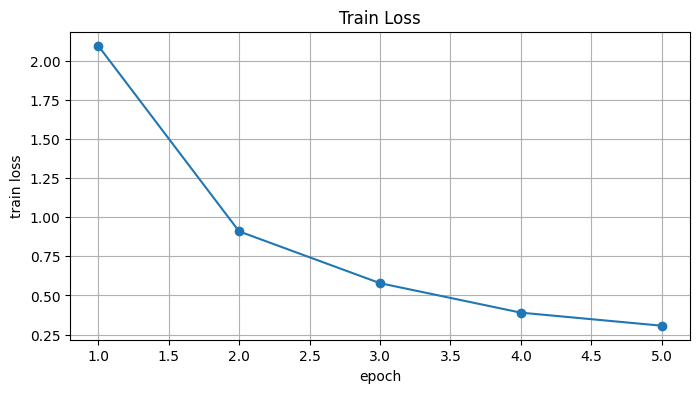

In [22]:
plt.figure(figsize=(8, 4))
plt.plot([h["epoch"] for h in history], [h["train_loss"] for h in history], marker="o")
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.title("Train Loss")
plt.grid(True)
plt.show()

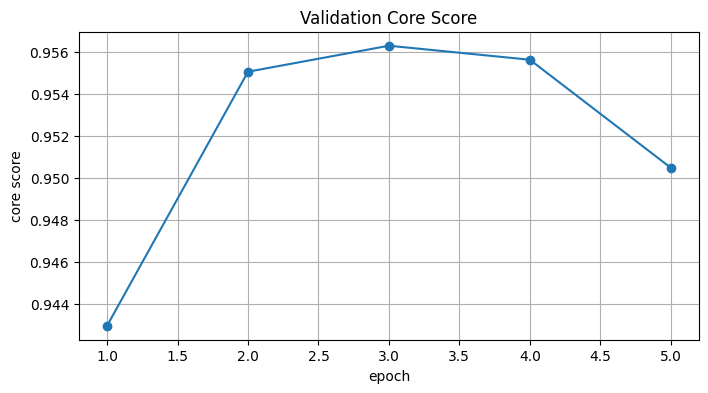

In [23]:
plt.figure(figsize=(8, 4))
plt.plot([h["epoch"] for h in history], [h["core_score"] for h in history], marker="o")
plt.xlabel("epoch")
plt.ylabel("core score")
plt.title("Validation Core Score")
plt.grid(True)
plt.show()

### Cell 17. head별 classification report

In [24]:
accs, all_true, all_pred = evaluate(model, val_loader)

for name in ["nearest_type", "nearest_distance", "nearest_horizontal", "visible_entity_count"]:
    print("=" * 80)
    print(name)

    if name == "nearest_type":
        target_names = TYPE_NAMES
    elif name == "nearest_distance":
        target_names = DISTANCE_BIN_NAMES
    elif name == "nearest_horizontal":
        target_names = HORIZONTAL_BIN_NAMES
    elif name == "visible_entity_count":
        target_names = COUNT_BIN_NAMES
    else:
        target_names = None

    print(classification_report(
        all_true[name],
        all_pred[name],
        target_names=target_names,
        digits=4,
        zero_division=0,
    ))

eval:   0%|          | 0/94 [00:00<?, ?it/s]/tmp/ipykernel_676428/3725012490.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and device == "cuda")):
eval: 100%|██████████| 94/94 [00:04<00:00, 23.23it/s]

nearest_type
              precision    recall  f1-score   support

        none     0.9935    0.9871    0.9903       155
      zombie     0.9840    0.9941    0.9891       682
    skeleton     0.9924    0.9835    0.9879       666

    accuracy                         0.9887      1503
   macro avg     0.9900    0.9882    0.9891      1503
weighted avg     0.9887    0.9887    0.9887      1503

nearest_distance
              precision    recall  f1-score   support

        none     0.9935    0.9871    0.9903       155
   too_close     0.9868    1.0000    0.9934       150
  attackable     0.8734    0.9876    0.9270       566
        near     0.9417    0.6052    0.7368       347
         far     0.8024    0.9404    0.8659       285

    accuracy                         0.8916      1503
   macro avg     0.9196    0.9041    0.9027      1503
weighted avg     0.8994    0.8916    0.8847      1503

nearest_horizontal
              precision    recall  f1-score   support

        none     0.9935   

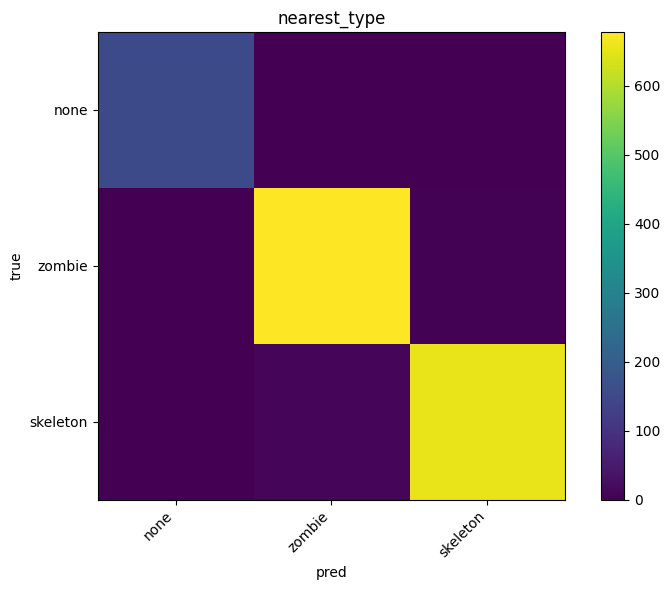

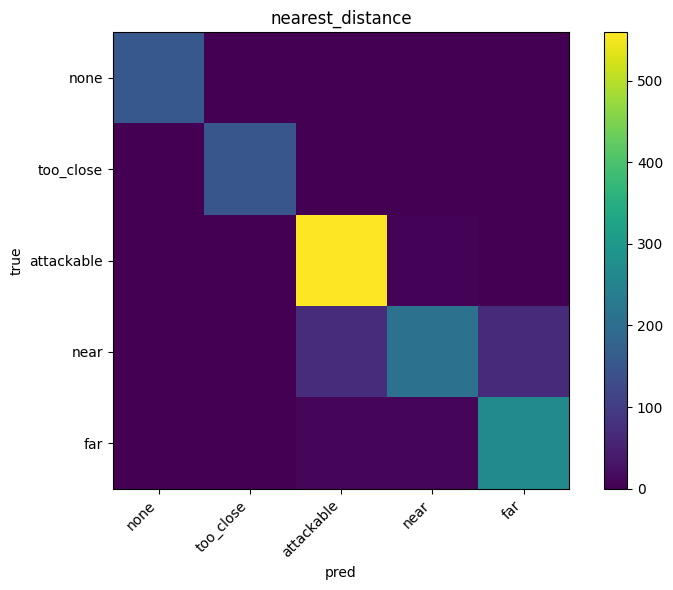

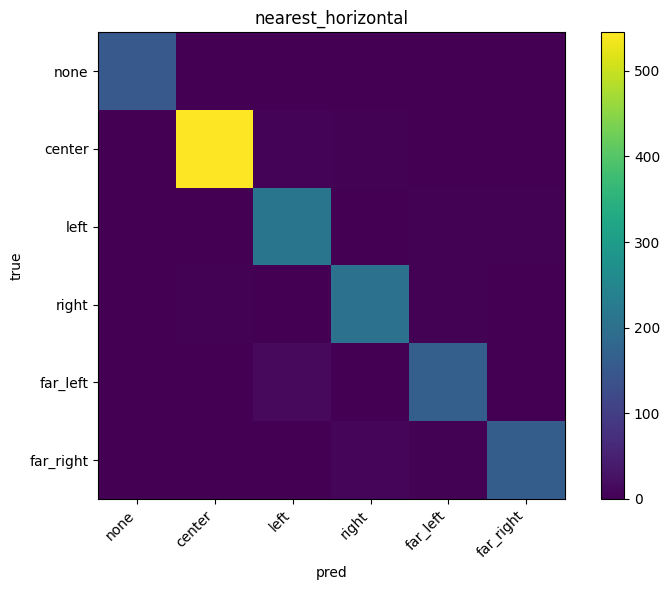

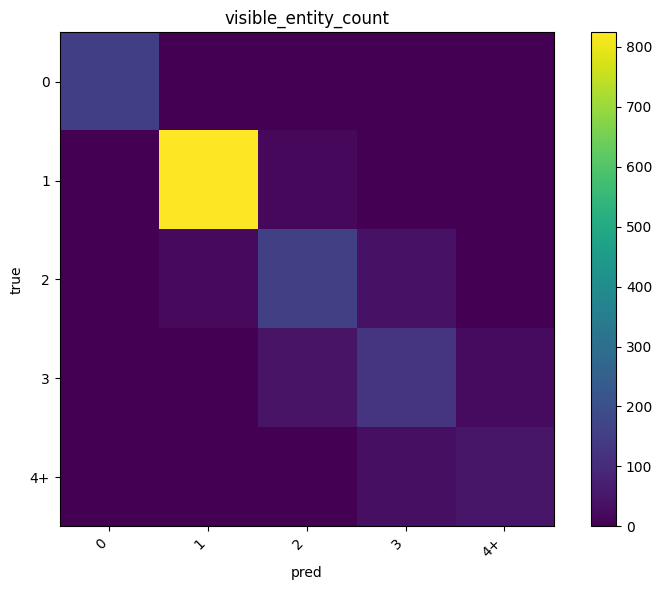

In [25]:
def plot_cm(name, names):
    cm = confusion_matrix(
        all_true[name],
        all_pred[name],
        labels=list(range(len(names))),
    )

    plt.figure(figsize=(8, 6))
    plt.imshow(cm)
    plt.title(name)
    plt.xticks(range(len(names)), names, rotation=45, ha="right")
    plt.yticks(range(len(names)), names)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


plot_cm("nearest_type", TYPE_NAMES)
plot_cm("nearest_distance", DISTANCE_BIN_NAMES)
plot_cm("nearest_horizontal", HORIZONTAL_BIN_NAMES)
plot_cm("visible_entity_count", COUNT_BIN_NAMES)

## ckp

In [19]:
checkpoint = torch.load(SAVE_PATH, map_location=device)

infer_model = SiglipSceneDescriptor(checkpoint["model_name"]).to(device)
infer_model.load_state_dict(checkpoint["model_state_dict"])
infer_model.eval()

print("loaded:", SAVE_PATH)

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 3275.89it/s]
[transformers] SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight

loaded: siglip_scene_descriptor.pt


In [20]:
@torch.no_grad()
def predict_scene(image_path):
    image = Image.open(image_path).convert("RGB")
    image = letterbox_to_square(image, IMAGE_SIZE)

    inputs = processor(
        images=[image],
        return_tensors="pt",
        do_resize=False,
    )

    pixel_values = inputs["pixel_values"].to(device)

    with torch.cuda.amp.autocast(enabled=(USE_AMP and device == "cuda")):
        outputs = infer_model(pixel_values)

    result = {}

    for name in HEAD_DIMS.keys():
        probs = torch.softmax(outputs[name], dim=1)[0]
        pred = int(probs.argmax().item())

        result[name] = {
            "id": pred,
            "prob": float(probs[pred].item()),
            "probs": probs.cpu().tolist(),
        }

    for name in BINARY_HEADS:
        prob = float(torch.sigmoid(outputs[name])[0].item())
        result[name] = {
            "value": prob >= 0.5,
            "prob": prob,
        }

    return result

In [21]:
def result_to_scene_text(result):
    has_entity = result["has_visible_entity"]["value"]

    if not has_entity:
        return "No hostile entity is visible."

    nearest_type = TYPE_NAMES[result["nearest_type"]["id"]]
    nearest_distance = DISTANCE_BIN_NAMES[result["nearest_distance"]["id"]]
    nearest_horizontal = HORIZONTAL_BIN_NAMES[result["nearest_horizontal"]["id"]]
    nearest_vertical = VERTICAL_BIN_NAMES[result["nearest_vertical"]["id"]]

    visible_count = COUNT_BIN_NAMES[result["visible_entity_count"]["id"]]
    zombie_count = COUNT_BIN_NAMES[result["visible_zombie_count"]["id"]]
    skeleton_count = COUNT_BIN_NAMES[result["visible_skeleton_count"]["id"]]

    too_close = result["nearest_too_close"]["value"]
    attackable = result["nearest_attackable"]["value"]
    multiple = result["multiple_entities"]["value"]

    text = ""

    text += f"Visible hostile entities: {visible_count}. "
    text += f"Visible zombies: {zombie_count}. "
    text += f"Visible skeletons: {skeleton_count}. "

    text += (
        f"The nearest visible entity is a {nearest_type}, "
        f"located at {nearest_horizontal} and {nearest_vertical}, "
        f"at {nearest_distance} distance. "
    )

    if too_close:
        text += "The nearest entity is too close. "

    if attackable:
        text += "The nearest entity is within attack range. "

    if multiple:
        text += "Multiple hostile entities are visible. "

    return text

In [22]:
sample = random.choice(val_samples)
image_path = sample["image_path"]

pred = predict_scene(image_path)
text = result_to_scene_text(pred)

print("image:", image_path)
print("GT scene text:")
print(sample["scene_text"])
print()
print("Predicted scene text:")
print(text)

img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(8, 4))
plt.imshow(img)
plt.axis("off")
plt.show()

NameError: name 'val_samples' is not defined